In [3]:
import torch
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# CUDA_VISIBLE_DEVICES=3 python3 main.py -r 100 -e 3 -bs 256 -t femnist -m fedavg -cn 10 --data-dir ./Data --client-dir None --degrade 0.0

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
def ploting(fedavg, fedprox, fedref, title="MNIST Classification", metric=["loss"], num=60, thresholds=[0.5,0.7,1], legend= False, start=5):
    # 예시 데이터
    fedref_colors = ["blue", "orange", "green", "lightcoral", "darkred", "tomato", "red", "khaki", "darkkhaki"]
    labels = ["FedAvg", "FedProx (μ:0.5)", "FedOpt (η:0.01, β1:0.9, β2:0.99, τ:1e-4)", "AdaBest (α:0.1 , β:1.0)", "FedEve (β:0.9, μ:0.01, ρ:0.9)",
              "A-FedPD (μ:0.1)", "FedRef (λ:0.01, ρ:4) client: FedAvg" , "FedRef (λ:0.01, ρ:4) client: FedProx", "FedRef (λ:0.1, ρ:8) client: FedAvg"]
    with plt.style.context('bmh'):
        fig, ax = plt.subplots(2, len(metric), figsize=(24, 8))
        for i, mtr in enumerate(metric):
            ax[0][i].plot(fedavg[mtr][start:num], marker=".",linestyle="--",label="fedavg", color=fedref_colors[0], alpha=0.5, linewidth=4)
            ax[0][i].plot(fedprox[mtr][start:num], marker=".", linestyle="--" ,label="fedprox(μ:0.5)", color=fedref_colors[1], alpha=0.5, linewidth=4)
            for i2,l in enumerate(fedref):
                ax[0][i].plot(l[mtr][start:num], marker=".", label=l["label"], color=fedref_colors[i2+2], linestyle="--", alpha=0.5, linewidth=4)

            # 메인 축 설정
            ax[0][i].set_xlabel("Rounds", fontsize=15)
            if mtr=="loss":
                ax[0][i].set_yscale("log")
            ax[0][i].set_ylabel(mtr, fontsize=15)
            ax[0][i].tick_params(axis='x', labelsize=15)
            ax[0][i].tick_params(axis='y', labelsize=15)

            ax[1][i].set_ylabel(mtr, fontsize=15)
            ax[1][i].set_xlabel("Rounds", fontsize=15)
            
            # ax.set_yticks([i for i in np.arange(0, 2*num+1, step=num) if i!=2*num], labels= [i if i!=2*num else "No reach" for i in range(0, 2*num+1, num) if i!=2*num], fontsize=15)
            ax[1][i].tick_params(axis='x', labelsize=15)
            ax[1][i].tick_params(axis='y', labelsize=15)
            for idx, t in enumerate(thresholds):
                try:
                    samples = {"v":[fedavg[mtr].iloc[t], fedprox[mtr].iloc[t], *[STRATEGY[mtr].iloc[t] for STRATEGY in fedref]], "colors":fedref_colors}
                    S=list(zip(samples["v"], samples["colors"]))
                    for idx2, s in enumerate(S):
                        ax[1][i].bar(idx+idx2*0.1-0.3, height=s[0], color =s[1], width=0.1, alpha=0.5)
                except:
                    break
            ax[1][i].set_xticks(range(len(thresholds)), [str(round(thresholds[len(thresholds)-i], 4)) for i in range(len(thresholds),0, -1)])
            
        h,l =ax[1][len(metric)//2].get_legend_handles_labels()
        for label in labels:
            l.append(label)
        h.extend([plt.Line2D([0], [0], color=fedref_colors[0], lw=4), plt.Line2D([0], [0], color=fedref_colors[1], lw=4)])
        for i in range(len(fedref)):
            h.append(plt.Line2D([0], [0], color=fedref_colors[i+2], lw=4))

            
        if legend == True:
            ax[1][len(metric)//2].legend(
                h, l,
                    loc="upper center",       # 범례 상자의 '위쪽 가운데'를 기준점으로 삼음
                    bbox_to_anchor=(0.5, -0.25), # 그래프 기준 가로 50%(중앙), 세로 -15%(아래 바깥) 위치
                    ncols=2,                   # 범례 아이템을 가로로 2개씩 나열
                    fontsize= 16
                )
        display(fig)


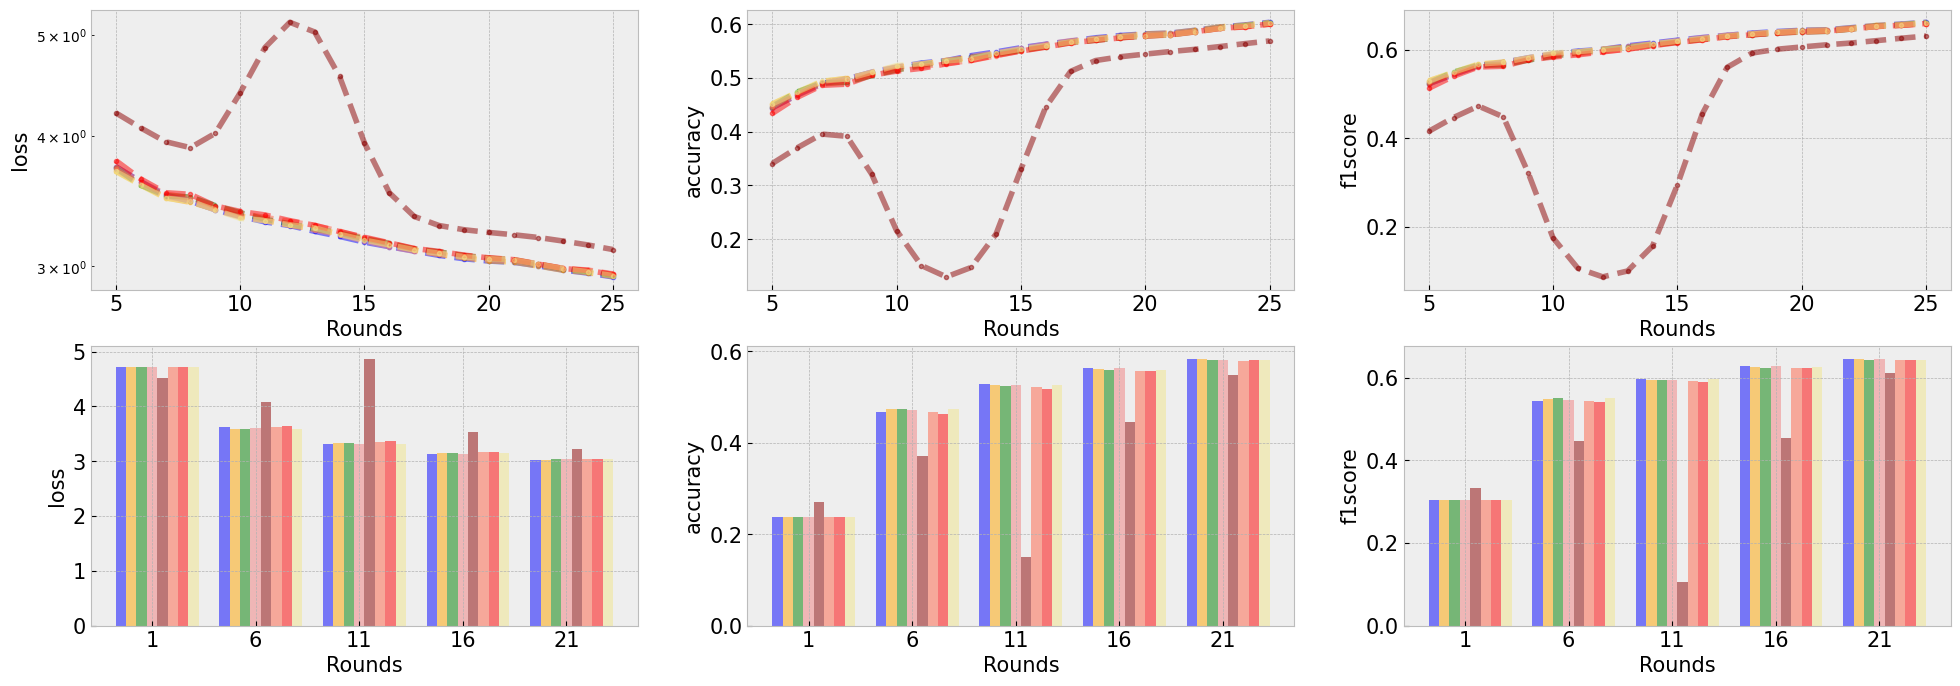

In [60]:
n = 26
thresholds=[i for i in range(1, n, 5)]
TYPE="fedavg"
root_dir = f"Result/{TYPE}/degrade0.2"
fedavg = pd.read_csv(root_dir+"/fedavg_femnist_lda0.1_p4.csv")
TYPE="fedprox"
root_dir = f"Result/{TYPE}/degrade0.2"
fedprox = pd.read_csv(root_dir+"/fedprox_femnist_lda0.1_p4.csv")
TYPE="fedopt"
root_dir = f"Result/{TYPE}/degrade0.2"
fedopt = pd.read_csv(root_dir+"/fedopt_femnist_lda0.1_p4.csv")
TYPE="adabest"
root_dir = f"Result/{TYPE}/degrade0.2"
adabest = pd.read_csv(root_dir+"/adabest_femnist_lda0.1_p4.csv")
TYPE="fedeve"
root_dir = f"Result/{TYPE}/degrade0.2"
fedeve = pd.read_csv(root_dir+"/fedeve_femnist_lda0.1_p4.csv")
TYPE="afedpd"
root_dir = f"Result/{TYPE}/degrade0.2"
afedpd = pd.read_csv(root_dir+"/afedpd_femnist_lda0.1_p4.csv")

TYPE="fedref"
root_dir = f"Result/{TYPE}/degrade0.2"

fedref = [{**fedopt.to_dict("series"), **{"label":"fedopt(η:0.01, β1:0.9, β2:0.99, τ:1e-4)"}},
          {**adabest.to_dict("series"), **{"label":"adabest(α:0.1 , β:1.0)"}},
          {**fedeve.to_dict("series"), **{"label":"fedeve(β:0.9, μ:0.01, ρ:0.9)"}},
          {**afedpd.to_dict("series"), **{"label":"afedpd(μ : 0.1)"}},
    {**pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda0.1_p4.csv").to_dict("series"), **{"label":"fedref(λ:0.01, ρ:4) Client: avg"}},
    {**pd.read_csv(root_dir+"/fedprox/fedref_femnist_lda0.1_p4.csv").to_dict("series"), **{"label":"fedref(λ:0.01, ρ:4) Client: prox"}},
    ]
ploting(fedavg, fedprox, fedref, title="FEMNIST Classification", metric=["loss", "accuracy", "f1score"], num=n, thresholds=thresholds)

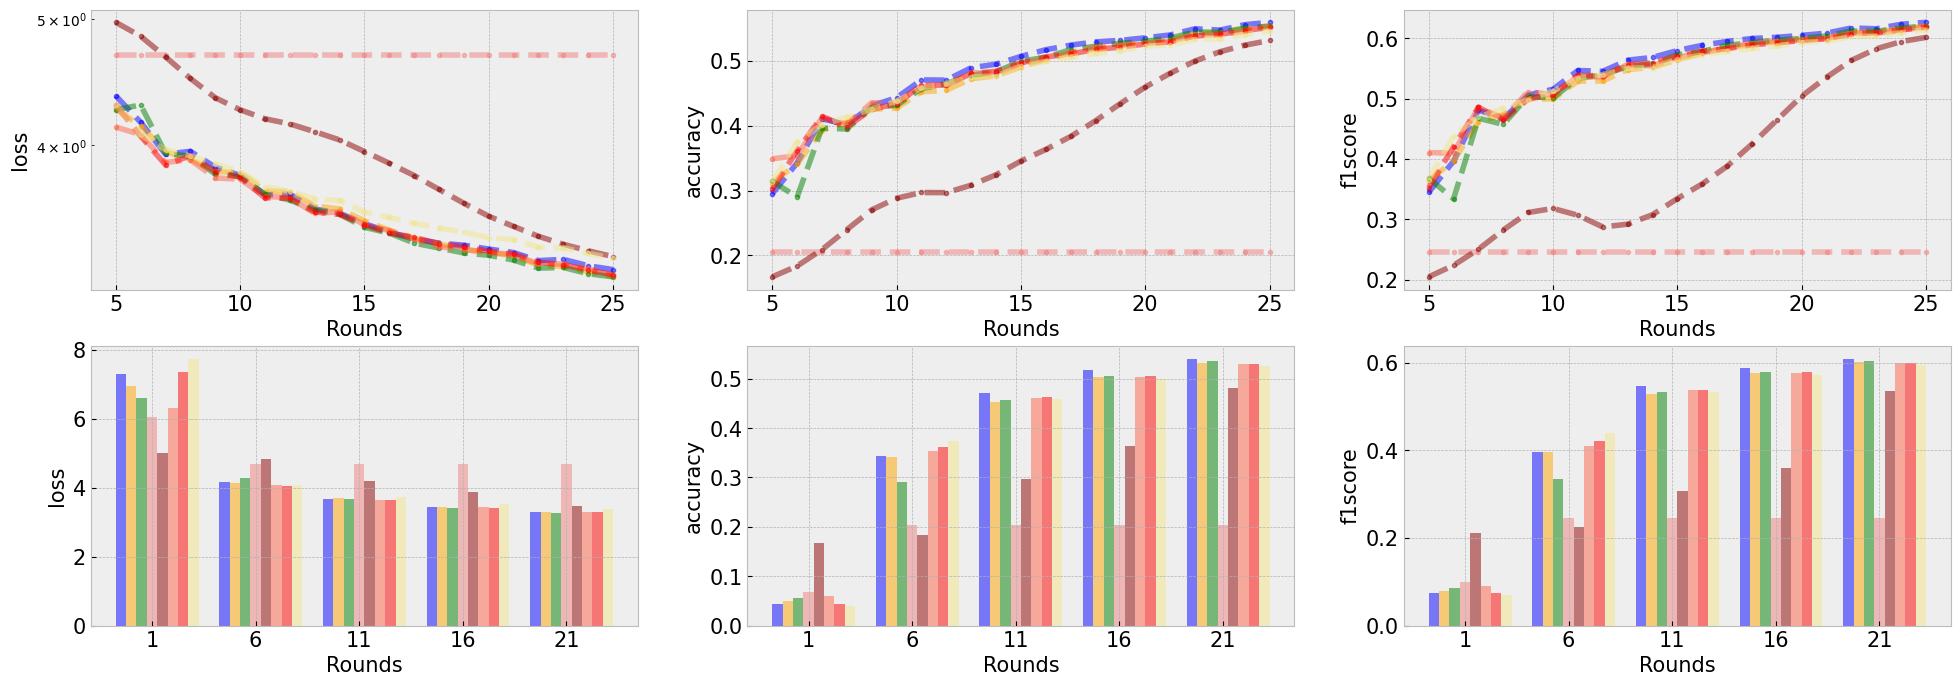

In [61]:
n = 26
thresholds=[i for i in range(1, n, 5)]
TYPE="fedavg"
root_dir = f"Result/{TYPE}/degrade0.4"
fedavg = pd.read_csv(root_dir+"/fedavg_femnist_lda0.1_p4.csv")
TYPE="fedprox"
root_dir = f"Result/{TYPE}/degrade0.4"
fedprox = pd.read_csv(root_dir+"/fedprox_femnist_lda0.1_p4.csv")
TYPE="fedopt"
root_dir = f"Result/{TYPE}/degrade0.4"
fedopt = pd.read_csv(root_dir+"/fedopt_femnist_lda0.1_p4.csv")
TYPE="adabest"
root_dir = f"Result/{TYPE}/degrade0.4"
adabest = pd.read_csv(root_dir+"/adabest_femnist_lda0.1_p4.csv")
TYPE="fedeve"
root_dir = f"Result/{TYPE}/degrade0.4"
fedeve = pd.read_csv(root_dir+"/fedeve_femnist_lda0.1_p4.csv")
TYPE="afedpd"
root_dir = f"Result/{TYPE}/degrade0.4"
afedpd = pd.read_csv(root_dir+"/afedpd_femnist_lda0.1_p4.csv")

TYPE="fedref"
root_dir = f"Result/{TYPE}/degrade0.4"

fedref = [{**fedopt.to_dict("series"), **{"label":"fedopt(η:0.01, β1:0.9, β2:0.99, τ:1e-4)"}},
          {**adabest.to_dict("series"), **{"label":"adabest(α:0.1 , β:1.0)"}},
          {**fedeve.to_dict("series"), **{"label":"fedeve(β:0.9, μ:0.01, ρ:0.9)"}},
          {**afedpd.to_dict("series"), **{"label":"afedpd(μ : 0.1)"}},
    {**pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda0.1_p4.csv").to_dict("series"), **{"label":"fedref(λ:0.01, ρ:4) Client: avg"}},
    {**pd.read_csv(root_dir+"/fedprox/fedref_femnist_lda0.1_p4.csv").to_dict("series"), **{"label":"fedref(λg:0.01, ρ:4) Client: prox"}},
    ]

ploting(fedavg, fedprox, fedref, title="FEMNIST Classification", metric=["loss", "accuracy", "f1score"], num=n, thresholds=thresholds)

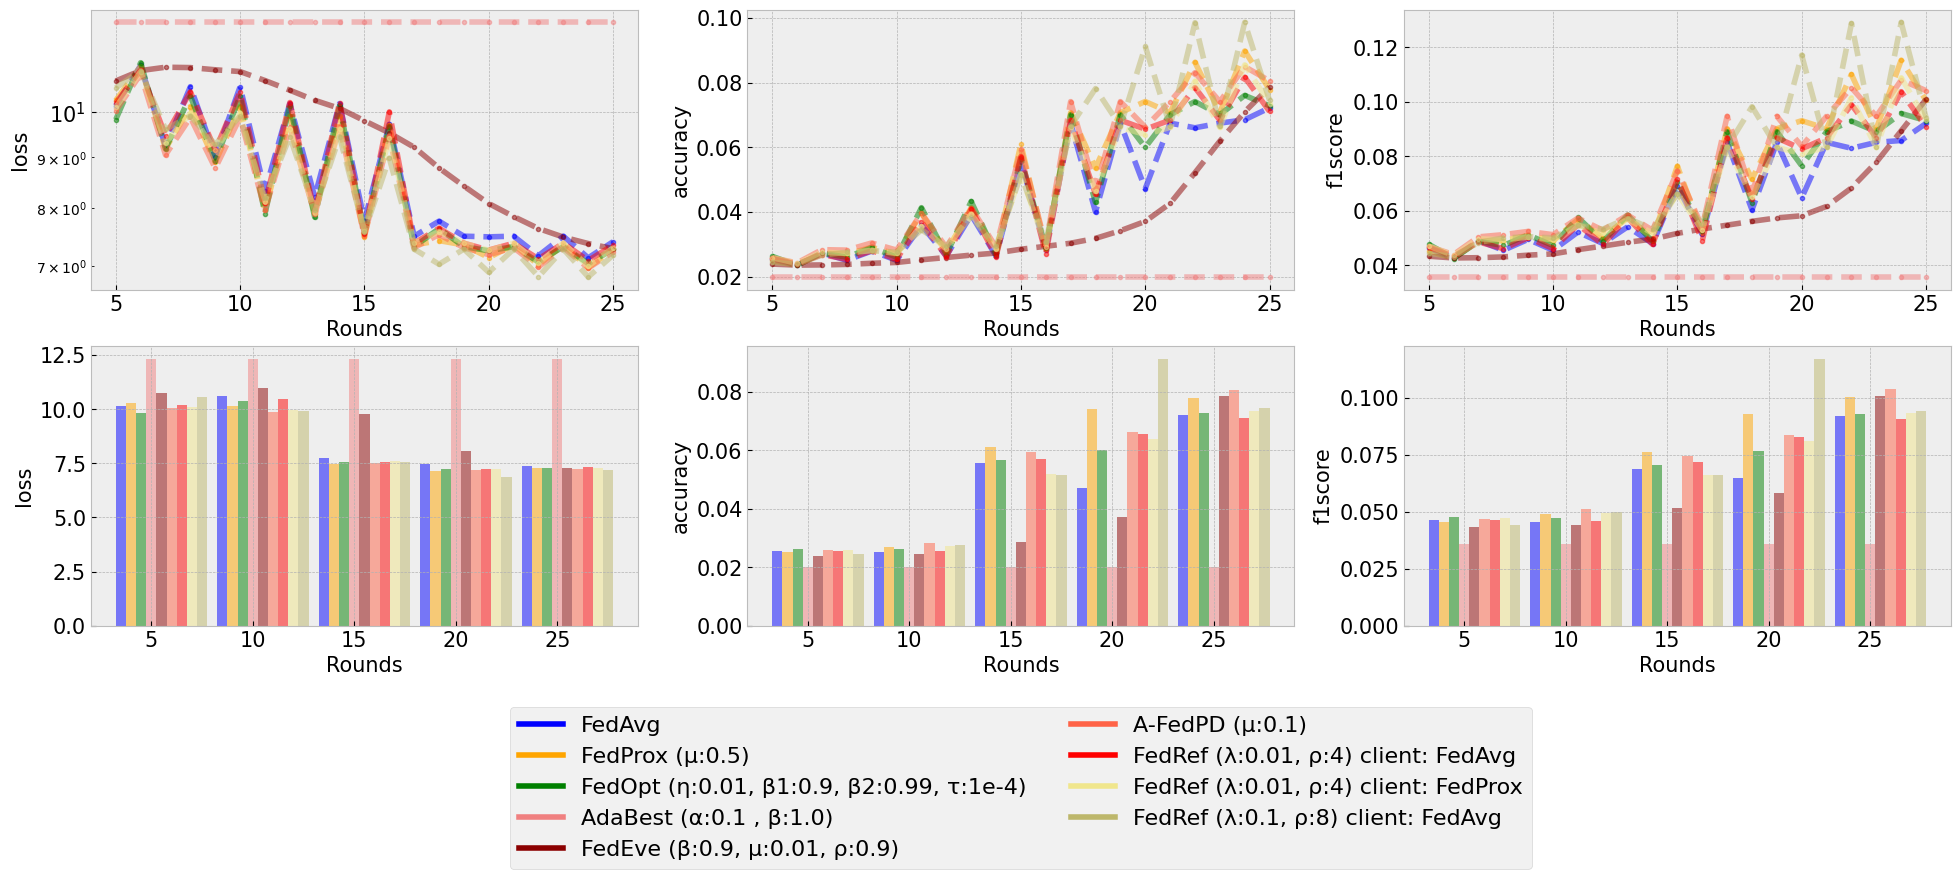

In [62]:
n = 26
thresholds=[i for i in range(5, n, 5)]
TYPE="fedavg"
root_dir = f"Result/{TYPE}/degrade0.8"
fedavg = pd.read_csv(root_dir+"/fedavg_femnist_lda0.1_p4.csv")
TYPE="fedprox"
root_dir = f"Result/{TYPE}/degrade0.8"
fedprox = pd.read_csv(root_dir+"/fedprox_femnist_lda0.1_p4.csv")
TYPE="fedopt"
root_dir = f"Result/{TYPE}/degrade0.8"
fedopt = pd.read_csv(root_dir+"/fedopt_femnist_lda0.1_p4.csv")
TYPE="adabest"
root_dir = f"Result/{TYPE}/degrade0.8"
adabest = pd.read_csv(root_dir+"/adabest_femnist_lda0.1_p4.csv")
TYPE="fedeve"
root_dir = f"Result/{TYPE}/degrade0.8"
fedeve = pd.read_csv(root_dir+"/fedeve_femnist_lda0.1_p4.csv")
TYPE="afedpd"
root_dir = f"Result/{TYPE}/degrade0.8"
afedpd = pd.read_csv(root_dir+"/afedpd_femnist_lda0.1_p4.csv")

TYPE="fedref"
root_dir = f"Result/{TYPE}/degrade0.8"

fedref = [{**fedopt.to_dict("series"), **{"label":"fedopt(η:0.01, β1:0.9, β2:0.99, τ:1e-4)"}},
          {**adabest.to_dict("series"), **{"label":"adabest(α:0.1 , β:1.0)"}},
          {**fedeve.to_dict("series"), **{"label":"fedeve(β:0.9, μ:0.01, ρ:0.9)"}},
          {**afedpd.to_dict("series"), **{"label":"afedpd(μ : 0.1)"}},
    {**pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda0.1_p4.csv").to_dict("series"), **{"label":"fedref(λ:0.01, ρ:4) Client: avg"}},
    {**pd.read_csv(root_dir+"/fedprox/fedref_femnist_lda0.1_p4.csv").to_dict("series"), **{"label":"fedref(λg:0.01, ρ:4) Client: prox"}},
    {**pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda1.0_p8.csv").to_dict("series"), **{"label":"fedref(λ:0.1, ρ:8) Client: avg"}}
    ]

ploting(fedavg, fedprox, fedref, title="FEMNIST Classification", metric=["loss", "accuracy", "f1score"], num=n, thresholds=thresholds, legend=True)


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def ablation_study(stratgies=["FedAvg", "FedProx", "A-FedPD"], source=[], targets=[[]], metrics= ["loss", "accuracy", "f1score"], legend=False, anchor= [45, 50], epsilon=(0.5, 0.015, 0.015), num=50):
    targets_colors = ["r", "brown", "lightcoral", "darkorange", "orange", "yellow"]
    with plt.style.context('bmh'):
        fig, ax = plt.subplots(len(stratgies), len(metrics), figsize=(24,4))
        for idx, (ST, S, TS) in enumerate(zip(stratgies, source, targets)):
            labels=[f"{ST}", f"{ST} Client + FedRef (λ:0.01, ρ:4)"
                    , f"{ST} Client + FedRef (λ:0.1, ρ:4)", f"{ST} Client + FedRef (λ:0.1, ρ:8)", f"{ST} Client + FedRef (λ:0.9, ρ:4)", f"{ST} Client + FedRef (λ:0.9, ρ:8)"]
            if len(stratgies) == 1:
                for idx2, m in enumerate(metrics):
                    if m == "loss":
                        axins = inset_axes(ax[idx2], width="35%", height="35%", borderpad=2)
                    else:
                        axins = inset_axes(ax[idx2], width="35%", height="35%", borderpad=2, loc="upper left")
                    
                    ax[idx2].set_xlabel("Rounds", fontsize=15)
                    ax[idx2].set_ylabel(m, fontsize=15)
                    ax[idx2].plot(S[m][:num], color="b" , marker=".",linestyle="--", alpha=0.5, linewidth=4)
                    axins.plot(S[m][:num], color="b" , marker=".",linestyle="--", alpha=0.5, linewidth=4)
                    for idx3, T in enumerate(TS):
                        ax[idx2].plot(T[m][:num], color=targets_colors[idx3] , marker=".",linestyle="--", alpha=0.5, linewidth=4)
                        axins.plot(T[m][:num], color=targets_colors[idx3] , marker=".",linestyle="--", alpha=0.5, linewidth=4)
                    axins.set_xlim(anchor[0]-0.5, anchor[1]+0.5)
                    axins.set_ylim(min(S[m][anchor[0]: anchor[1]+1])-epsilon[idx2], max(S[m][anchor[0]: anchor[1]+1])+epsilon[idx2])
                    if m == "loss":
                        mark_inset(ax[idx2], axins, loc1=3, loc2=4, fc="none", ec="black", linestyle="--")
                    else:
                        mark_inset(ax[idx2], axins, loc1=3, loc2=4, fc="none", ec="black", linestyle="--")
                h,l =ax[len(metrics)//2].get_legend_handles_labels()
                h.extend([plt.Line2D([0], [0], color="b", lw=4)])
                for idx2, label in enumerate(labels):
                    l.append(label)  
                    h.append(plt.Line2D([0], [0], color=targets_colors[idx2], lw=4))

                if legend == True:
                    ax[len(metrics)//2].legend(
                        h, l,
                            ncols=2,                   
                            fontsize= 16,
                            bbox_to_anchor=[1.25, -0.15]
                        )
            else:
                assert ValueError

    display(fig)

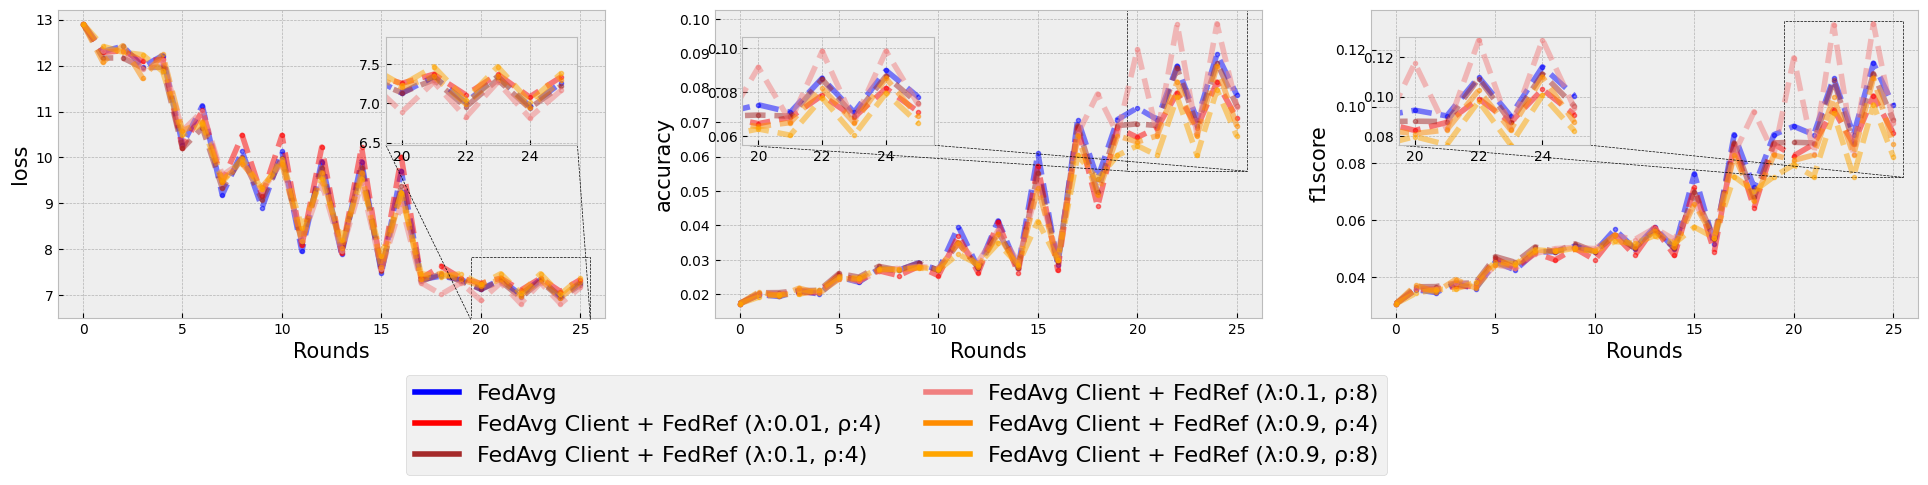

In [64]:
n = 26
TYPE="fedavg"
root_dir = f"Result/{TYPE}/degrade0.8"
fedavg = pd.read_csv(root_dir+"/fedavg_femnist_lda0.1_p4.csv")
TYPE="fedprox"
root_dir = f"Result/{TYPE}/degrade0.8"
fedprox = pd.read_csv(root_dir+"/fedprox_femnist_lda0.1_p4.csv")
TYPE="afedpd"
root_dir = f"Result/{TYPE}/degrade0.8"
afedpd = pd.read_csv(root_dir+"/afedpd_femnist_lda0.1_p4.csv")

TYPE="fedref"
root_dir = f"Result/{TYPE}/degrade0.8"
targets = [[pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda0.1_p4.csv")],
           [pd.read_csv(root_dir+"/fedprox/fedref_femnist_lda0.1_p4.csv")]]

ablation_study(stratgies=["FedAvg"], source=[fedprox], targets=[[pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda0.1_p4.csv"),
                                                                 pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda1.0_p4.csv"),
                                                                 pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda1.0_p8.csv"),
                                                                 pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda9.0_p4.csv"),
                                                                 pd.read_csv(root_dir+"/fedavg/fedref_femnist_lda9.0_p8.csv"),
                                                                 ]], legend=True, anchor=[20,25], num=n)
# ablation_study(stratgies=["FedProx"], source=[fedprox], targets=[[pd.read_csv(root_dir+"/fedprox/fedref_femnist_lda0.1_p4.csv")]

#                                                                             ], legend=True)